In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os


In [2]:
path_to_data = 'C:/Users/gabriel.battcock/OneDrive - World Food Programme/General - MIMI Project/Countries/Sri Lanka/data/'

In [3]:
food_security = pd.read_excel(path_to_data + "food_security_survey_2024/data-fs-sp_final-v2.xlsx")

In [4]:
path_to_hies =  "HIES_2019/HIES_2019/"
animal = pd.read_csv(path_to_data +path_to_hies+"SECTION_9_2_OWNED_LIVESTOCKS.csv")
income =  pd.read_csv(path_to_data +path_to_hies+"HH_expenditure_hh_Income.csv")

In [6]:
# makes hhid 
def make_hhid(df):
    # Ensure all parts are strings and handle missing values
    df['hhid'] = (
        df['psu'].astype(str).str.strip() +
        df['snumber'].astype(str).str.strip() +
        df['hhno'].astype(str).str.strip()
    ).astype(int)

make_hhid(animal)
make_hhid(income)

In [7]:
animal

,district,sector,month,psu,snumber,hhno,nhh,result,s9_cattle_buffaloes,cows_count,goats_sheeps,goat_count,pigs,pigs_count,chickens,chicken_count,other_animals,other_count,hhid
0,11,1,1,111088,1,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108811
1,11,1,1,111088,3,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108831
2,11,1,1,111088,5,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108851
3,11,1,1,111088,6,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108861
4,11,1,1,111088,7,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19906,92,3,12,192085,6,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208561
19907,92,3,12,192085,7,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208571
19908,92,3,12,192085,8,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208581
19909,92,3,12,192085,9,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208591


In [44]:
# 2019 data
def get_asw_animal_2019(df):
    df['asw_animal'] = (
        ((df['s9_cattle_buffaloes'] == 1) & (df['cows_count'] >= 5)) |
        ((df['goats_sheeps']== 1) & (df['goat_count']>=20)) |
        ((df['pigs']==1) & (df['pigs_count']>=10)) |
        ((df['chickens']) & (df['chicken_count']>=50))

    ).astype(int)

    df = df[['hhid','asw_animal']]
    return df

animal_19 = get_asw_animal_2019(animal)


In [9]:
def get_asw_animal_2024(df):

    df['asw_animal'] = (
        (df['PMT_number_animals_cattle'] >=5) |
        (df['PMT_number_animals_pig'] >=10 ) |
        (df['PMT_number_animals_goat'] >=10) |
        (df['PMT_number_animals_chicken'] >=50)
    ).astype(int)
    df = df[['@_id','asw_animal']]
    return df
animal_24 = get_asw_animal_2024(food_security)

1500.0


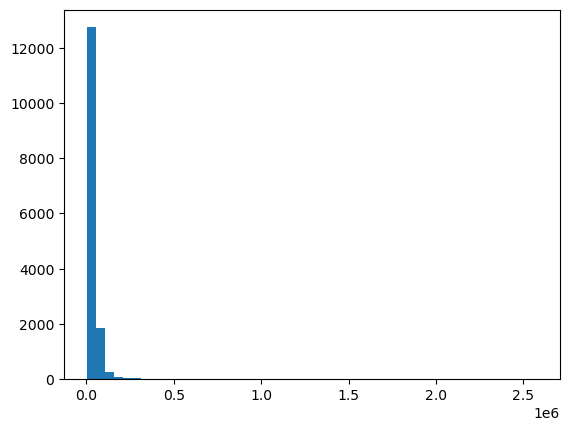

In [17]:

plt.hist(food_security['totalNFMonthly'], bins = 50)



In [32]:

print(food_security.columns.tolist())

['start', 'end', 'today', 'deviceid', 'TechnicalBasic_submoduleSvyDate', 'TechnicalBasic_submoduleSupvName', 'TechnicalBasic_submodulesupv_other', 'EnuName', 'enu_other', 'Province', 'Disitrict', 'DSDivison', 'GNDivison', 'OtherGNdivisonSpecifiy', 'sector', 'RESPConsent', 'resp_refusalwhy', 'resp_ref_other', 'EnuComments', 'resp_firstname', 'resp_lastname', 'RESPAge', 'RESPSex', 'RESPRelationHHH', 'RESPRelationHHH_oth', 'HHHAge', 'HHHSex', 'hh_education', 'hh_maritalstat', 'HHSize', 'HHSize01F', 'HHSize24F', 'HHSize511F', 'fem_hhmemHHSize1217F', 'fem_hhmemHHSize1859F', 'fem_hhmemHHSize59upF', 'male_hhmemHHSize01M', 'male_hhmemHHSize24M', 'male_hhmemHHSize511M', 'male_hhmemHHSize1217M', 'male_hhmemHHSize1859M', 'male_hhmemHHSize59upM', 'HHSize_calc', 'PMT_Education1', 'PMT_Education2', 'HHSizeRep', 'HHSizePlw', 'HHmem0_14', 'HHMem64above', 'HHmem1564', 'PMT_HHSizeCronDi', 'PMT_HHSizewhatcr', 'PMT_HHSizewhatcr1', 'PMT_HHSizewhatcr2', 'PMT_HHSizewhatcr3', 'PMT_HHSizewhatcr4', 'PMT_HHSizew

# Income

In [33]:
def get_asw_perexp_2024(df):

    df['TotalConsumption'] = (df['TotalFexpMonthly'] + df['totalNFMonthly'])/df['HHSize']

    df['asw_perexp_poor'] = (
        df['TotalConsumption']<16000
    ).astype(int)

    df = df[['@_id', 'asw_perexp_poor']]
    return df

poverty_24 = get_asw_perexp_2024(food_security)

In [56]:
poverty_24[poverty_24['asw_perexp_poor']==1]

,@_id,asw_perexp_poor
0,64979777,1
3,65031840,1
4,64977799,1
7,64978857,1
8,65560777,1
...,...,...
15092,66442323,1
15093,66442324,1
15096,66449825,1
15097,66449828,1


In [52]:
poverty_24

,@_id,asw_perexp_poor
0,64979777,1
1,64864373,0
2,65572640,0
3,65031840,1
4,64977799,1
...,...,...
15095,66449824,0
15096,66449825,1
15097,66449828,1
15098,66449829,1


In [49]:
def get_asw_perexp_2019(df):
    # change based on inflation
    df['asw_perexp_poor'] =(df['hhexppm']/df['hhsize']  < 8104).astype(int)

    df = df[['hhid','asw_perexp_poor']]
    return df

poverty19 = get_asw_perexp_2019(income)

In [45]:
poverty19.to_csv('../../data/processed/features/asw_perexp_2019.csv')
poverty_24.to_csv('../../data/processed/features/asw_perexp_2024.csv')
animal_24.to_csv('../../data/processed/features/asw_animal_2024.csv')
animal_19.to_csv('../../data/processed/features/asw_animal_2019.csv')

Look at the features compared to mimi simple

In [51]:
poverty19[poverty19['asw_perexp_poor']==1]
# poverty19

,hhid,asw_perexp_poor
26,11104551,1
75,11109721,1
132,11100771,1
133,11100781,1
166,111009101,1
...,...,...
19888,19206711,1
19894,19204011,1
19903,19208531,1
19907,19208571,1


In [39]:
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-11-13.csv")

In [40]:
poverty_targets = ml_targets[['hhid', 'overall_mar']].merge(poverty19)
poverty_targets

,hhid,overall_mar,asw_perexp_poor
0,11100111,0.594869,0
1,11100121,0.864046,0
2,11100131,0.636291,0
3,11100141,0.480061,1
4,11100151,0.667098,0
...,...,...,...
19906,19208551,0.566066,1
19907,19208561,0.680711,1
19908,19208571,0.455042,1
19909,19208581,0.589026,1


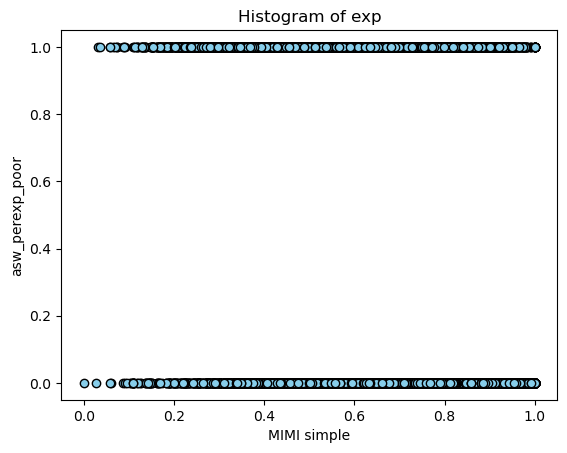

In [41]:

plt.scatter(poverty_targets[['overall_mar']],poverty_targets['asw_perexp_poor'],  color='skyblue', edgecolor='black')
plt.title('Histogram of exp')
plt.xlabel('MIMI simple')
plt.ylabel('asw_perexp_poor')
plt.show()


In [42]:
animal_targets = ml_targets[['hhid', 'overall_mar']].merge(animal_new)
animal_targets

,hhid,overall_mar,asw_animal
0,11100111,0.594869,0
1,11100121,0.864046,0
2,11100131,0.636291,0
3,11100141,0.480061,0
4,11100151,0.667098,0
...,...,...,...
19906,19208551,0.566066,0
19907,19208561,0.680711,0
19908,19208571,0.455042,0
19909,19208581,0.589026,0


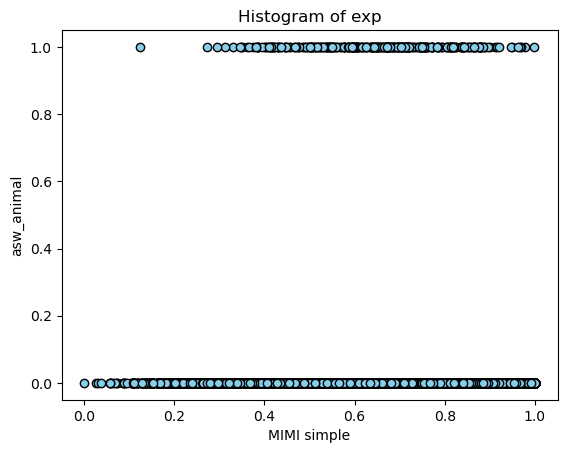

In [43]:
plt.scatter(animal_targets[['overall_mar']],animal_targets['asw_animal'],  color='skyblue', edgecolor='black')
plt.title('Histogram of exp')
plt.xlabel('MIMI simple')
plt.ylabel('asw_animal')
plt.show()